In [ ]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/emnist-digits-balanced")
print("Path to dataset files:", path)

DATA_DIR = path

# Global access and constants
IMG_SIZE = (28, 28)
BATCH_SIZE = 128
SEED = 42
epochs = 250

train_ds, val_ds, test_ds, preprocessing_model = None, None, None, None

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    global IMG_SIZE
    global BATCH_SIZE
    global SEED

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model

Using Colab cache for faster access to the 'emnist-digits-balanced' dataset.
Path to dataset files: /kaggle/input/emnist-digits-balanced


# Learnable Pooling Module

In [35]:
# ============================================
# 1. Learnable Pooling Module (LPM) Components
# ============================================
@register_keras_serializable(package="Custom")
class LearnablePoolingModule(layers.Layer):
    """
    Implements the LPM that learns a non-uniform grid for pooling.
    Based on Ogusu & Yamanaka (2019).
    """
    def __init__(self, output_size=(14, 14), **kwargs):
        super().__init__(**kwargs)
        self.output_size = output_size

    def build(self, input_shape):
        # Sub-network to predict grid offsets
        # It takes the feature map and outputs offsets for rows and columns
        self.offset_net = models.Sequential([
            layers.GlobalAveragePooling2D(),
            layers.Dense(32, activation='relu'),
            # Predict output_size[0] offsets for X and output_size[1] for Y
            layers.Dense(self.output_size[0] + self.output_size[1], kernel_initializer='zeros')
        ])
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        img_h, img_w = tf.shape(inputs)[1], tf.shape(inputs)[2]

        # 1. Predict offsets and normalize to [0, 1] range
        offsets = self.offset_net(inputs)
        offsets_x = tf.nn.softmax(offsets[:, :self.output_size[0]])
        offsets_y = tf.nn.softmax(offsets[:, self.output_size[0]:])

        # 2. Convert relative offsets to cumulative grid coordinates
        grid_x = tf.cumsum(offsets_x, axis=1) * tf.cast(img_w - 1, tf.float32)
        grid_y = tf.cumsum(offsets_y, axis=1) * tf.cast(img_h - 1, tf.float32)

        # Vectorized interpolation across the batch
        outputs = tf.vectorized_map(
            lambda i: self._interpolate(inputs[i], grid_x[i], grid_y[i]),
            tf.range(batch_size)
        )
        return outputs

    def _interpolate(self, img, grid_x, grid_y):
        # img: [H, W, C]
        # grid_x: [W_out] - 1D tensor of x-coordinates for output width
        # grid_y: [H_out] - 1D tensor of y-coordinates for output height

        # Create a 2D grid of sampling points from the learned 1D coordinates
        gx, gy = tf.meshgrid(grid_x, grid_y, indexing='xy')

        # Ensure coordinates are float32
        gy_f = tf.cast(gy, tf.float32)
        gx_f = tf.cast(gx, tf.float32)

        # Calculate floor and ceil for interpolation
        y0 = tf.cast(tf.math.floor(gy_f), tf.int32)
        y1 = tf.cast(tf.math.ceil(gy_f), tf.int32)
        x0 = tf.cast(tf.math.floor(gx_f), tf.int32)
        x1 = tf.cast(tf.math.ceil(gx_f), tf.int32)

        # Clip indices to image bounds to prevent out-of-bounds access
        y_max = tf.shape(img)[0] - 1
        x_max = tf.shape(img)[1] - 1
        y0 = tf.clip_by_value(y0, 0, y_max)
        y1 = tf.clip_by_value(y1, 0, y_max)
        x0 = tf.clip_by_value(x0, 0, x_max)
        x1 = tf.clip_by_value(x1, 0, x_max)

        # Stack coordinates for tf.gather_nd
        coords_00 = tf.stack([y0, x0], axis=-1)  # [H_out, W_out, 2]
        coords_01 = tf.stack([y0, x1], axis=-1)
        coords_10 = tf.stack([y1, x0], axis=-1)
        coords_11 = tf.stack([y1, x1], axis=-1)

        # Gather pixel values from the four corners
        # img: [H, W, C], output will be [H_out, W_out, C]
        Ia = tf.gather_nd(img, coords_00)
        Ib = tf.gather_nd(img, coords_01)
        Ic = tf.gather_nd(img, coords_10)
        Id = tf.gather_nd(img, coords_11)

        # Calculate interpolation weights
        # Expand dims to broadcast weights across channels (C)
        wa = tf.expand_dims((tf.cast(x1, tf.float32) - gx_f) * (tf.cast(y1, tf.float32) - gy_f), axis=-1)
        wb = tf.expand_dims((gx_f - tf.cast(x0, tf.float32)) * (tf.cast(y1, tf.float32) - gy_f), axis=-1)
        wc = tf.expand_dims((tf.cast(x1, tf.float32) - gx_f) * (gy_f - tf.cast(y0, tf.float32)), axis=-1)
        wd = tf.expand_dims((gx_f - tf.cast(x0, tf.float32)) * (gy_f - tf.cast(y0, tf.float32)), axis=-1)

        # Perform bilinear interpolation
        output = wa * Ia + wb * Ib + wc * Ic + wd * Id
        return output

# Base Model

In [36]:
# ============================================
# 2. Modified VGG Model with LPM
# ============================================
def base_vgg_lpm_model(preprocessing_layer):
    l2_reg = regularizers.l2(1e-4)

    def vgg_block(x, filters, num_convs, block_id):
        for i in range(num_convs):
            x = layers.Conv2D(filters, (3, 3), padding='same',
                              kernel_initializer='he_normal',
                              kernel_regularizer=l2_reg,
                              name=f'block{block_id}_conv{i+1}')(x)
            x = layers.BatchNormalization(name=f'block{block_id}_bn{i+1}')(x)
            x = layers.Activation('relu', name=f'block{block_id}_relu{i+1}')(x)

        # Standard pooling is used after the initial LPM compression
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'block{block_id}_pool')(x)
        return x

    # --- Construct Model ---
    inputs = layers.Input(shape=(28, 28, 1))
    # Apply preprocessing first to inputs
    processed_inputs = preprocessing_layer(inputs)

    # Main path through LPM and VGG block
    x = LearnablePoolingModule(output_size=(14, 14), name="LPM_Layer")(processed_inputs)
    # After vgg_block, x will be (None, 7, 7, 32)
    x = vgg_block(x, 32, num_convs=2, block_id=1)

    # Shortcut path: Transform processed_inputs (28x28x1) to match x (7x7x32)
    # Use a 1x1 convolution with appropriate strides to downsample and adjust channels
    shortcut_path = layers.Conv2D(32, (1, 1), strides=(4, 4), padding='same',
                                  kernel_initializer='he_normal',
                                  kernel_regularizer=l2_reg,
                                  name='shortcut_transform')(processed_inputs)

    # Merge main path and shortcut path
    merged = layers.Add(name='shortcut_add')([x, shortcut_path])

    # Classification Head
    x = layers.Flatten()(merged)
    x = layers.Dense(64, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="VGG_LPM_EMNIST")

    return model

# Initialize
train_data, val_data, test_data, prep_layer = get_keras_dataset()
base_model = base_vgg_lpm_model(prep_layer)
base_model.summary()

--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.
Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Model: "VGG_LPM_EMNIST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing_head  │ (None, 28, 28, 1) │          3 │ input_layer_16[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LPM_Layer           │ (None, 14, 14, 1) │        988 │ preprocessing_he… │
│ (LearnablePoolingM… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 14, 14,    │        320 │ LPM_Layer[0][0]   │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn1          │ (None, 14, 14,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 14, 14,    │          0 │ block1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 14, 14,    │      9,248 │ block1_relu1[0][… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_bn2          │ (None, 14, 14,    │        128 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu2        │ (None, 14, 14,    │          0 │ block1_bn2[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 7, 7, 32)  │          0 │ block1_relu2[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut_transform  │ (None, 7, 7, 32)  │         64 │ preprocessing_he… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shortcut_add (Add)  │ (None, 7, 7, 32)  │          0 │ block1_pool[0][0… │
│                     │                   │            │ shortcut_transfo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1568)      │          0 │ shortcut_add[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │    100,416 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_28[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 10)        │        650 │ dropout_2[0][0] 

 Total params: 112,201 (438.29 KB)

 Trainable params: 111,942 (437.27 KB)

 Non-trainable params: 259 (1.02 KB)

# Dual Optimizer Model

In [37]:
optimizer_vgg, optimizer_lpm = None, None

@register_keras_serializable(package="Custom")
class DualOptimizerModel(tf.keras.Model):
    def __init__(self, model_arch, optimizer_vgg, optimizer_lpm, **kwargs):
        super(DualOptimizerModel, self).__init__(**kwargs)
        self.model_arch = model_arch # Your VGG + LPM model
        self.optimizer_vgg = optimizer_vgg
        self.optimizer_lpm = optimizer_lpm

        # Separate parameters once during initialization
        lpm_vars_raw = self.model_arch.get_layer("LPM_Layer").trainable_variables
        lpm_param_ids = {id(v) for v in lpm_vars_raw}
        self.lpm_trainable_variables = lpm_vars_raw
        self.vgg_trainable_variables = [v for v in self.model_arch.trainable_variables if id(v) not in lpm_param_ids]

    def call(self, inputs, training=False):
        # Delegate the call to the internal model architecture
        return self.model_arch(inputs, training=training)


    def train_step(self, data):
        # Unpack the data
        images, labels = data

        with tf.GradientTape(persistent=True) as tape:
            predictions = self.model_arch(images, training=True)
            # Use compute_loss instead of compiled_loss
            loss = self.compute_loss(y=labels, y_pred=predictions)
            if self.losses:
                loss += tf.add_n(self.losses)

        # --- Apply Gradients using pre-separated lists ---
        grads_vgg = tape.gradient(loss, self.vgg_trainable_variables)
        self.optimizer_vgg.apply_gradients(zip(grads_vgg, self.vgg_trainable_variables))

        grads_lpm = tape.gradient(loss, self.lpm_trainable_variables)
        self.optimizer_lpm.apply_gradients(zip(grads_lpm, self.lpm_trainable_variables))

        del tape

        # Update the states of all compiled metrics (iterating as recommended)
        for metric in self.metrics:
            if metric.name == 'loss':
                metric.update_state(loss)
            else:
                metric.update_state(labels, predictions)

        # Return the results of all metrics
        return {m.name: m.result() for m in self.metrics}

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "model_arch_config": self.model_arch.get_config(),
                "optimizer_vgg_config": tf.keras.optimizers.serialize(self.optimizer_vgg),
                "optimizer_lpm_config": tf.keras.optimizers.serialize(self.optimizer_lpm),
            }
        )
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        if custom_objects is None:
            custom_objects = {}
        custom_objects['LearnablePoolingModule'] = LearnablePoolingModule

        # Reconstruct the model_arch
        model_arch = tf.keras.Model.from_config(config['model_arch_config'],
                                                custom_objects=custom_objects)
        # Reconstruct the optimizers
        optimizer_vgg = tf.keras.optimizers.deserialize(config['optimizer_vgg_config'])
        optimizer_lpm = tf.keras.optimizers.deserialize(config['optimizer_lpm_config'])

        return cls(model_arch, optimizer_vgg, optimizer_lpm)


# In your custom train_step or using a wrapper:
optimizer_vgg = tf.keras.optimizers.Adam(learning_rate=0.001)

# Based on get_keras_dataset output: "Using 192000 files for training."
num_train_samples = 192000
# BATCH_SIZE is defined globally
steps_per_epoch = int(np.ceil(num_train_samples / 128))
total_training_steps = epochs * steps_per_epoch

print(f"Calculated Steps per epoch: {steps_per_epoch:,}")
print(f"Calculated Total training steps: {total_training_steps:,}")

# ============================================
# --- SGD Optimizer for LPM (Ogusu 2019 Paper Specification) ---
# The paper uses a high initial LR (1e-2) to allow the grid to
# spatially migrate across the image to find features.
# ============================================
optimizer_lpm = tf.keras.optimizers.SGD(
    learning_rate=0.01, # Initial LR from paper
    momentum=0.9,       # Standard momentum for stable grid movement
    nesterov=True
)

# Standard Adam for the rest of the VGG backbone
optimizer_vgg = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Create the DualOptimizerModel with the actual Keras model instance
model = DualOptimizerModel(base_model, optimizer_vgg, optimizer_lpm)
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)
model.summary()


Calculated Steps per epoch: 1,500
Calculated Total training steps: 375,000


Model: "dual_optimizer_model_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ VGG_LPM_EMNIST (Functional)     │ (None, 10)             │       112,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,201 (438.29 KB)

 Trainable params: 111,942 (437.27 KB)

 Non-trainable params: 259 (1.02 KB)

# Visualize LPM Grids

In [38]:
def visualize_emnist_lpm_grid(model, image_sample,
                              title="Before Training LPM Grid Density"):

    # 1. Ensure image is in the correct shape (Batch, H, W, C)
    if len(image_sample.shape) == 2:
        img_input = np.expand_dims(np.expand_dims(image_sample, axis=0), axis=-1)
    else:
        img_input = np.expand_dims(image_sample, axis=0)

    # 2. Access the LPM Layer and its internal offset_net
    # Note: 'LPM_Layer' must match the name used in your base_vgg_lpm_model [cite: 49]
    lpm_layer = model.model_arch.get_layer("LPM_Layer") # Corrected line

    # 3. Predict the raw offsets for this specific image
    raw_offsets = lpm_layer.offset_net(img_input)

    # 4. Process offsets as done in the 'call' method
    out_h, out_w = lpm_layer.output_size

    # Apply softmax to get relative spacing (summing to 1)
    off_x = tf.nn.softmax(raw_offsets[:, :out_w]).numpy()[0]
    off_y = tf.nn.softmax(raw_offsets[:, out_w:]).numpy()[0]

    # Convert to cumulative pixel coordinates (28x28 space)
    # Using 27 as the multiplier to map to the 0-27 pixel index range
    grid_x = np.cumsum(off_x) * 27
    grid_y = np.cumsum(off_y) * 27

    # 5. Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(image_sample.squeeze(), cmap='gray')

    # Draw vertical grid lines (X coordinates)
    for x in grid_x:
        plt.axvline(x=x, color='lime', linestyle='--', alpha=0.6, linewidth=1)

    # Draw horizontal grid lines (Y coordinates)
    for y in grid_y:
        plt.axhline(y=y, color='lime', linestyle='--', alpha=0.6, linewidth=1)

    plt.title(title)
    plt.axis('off')
    plt.show()

# Initialize Optimizers

In [39]:
# Explicitly build optimizers by applying dummy gradients
# This ensures optimizers have created their internal variables before train_step is tf.function compiled
dummy_gradients_vgg = [tf.zeros_like(var) for var in model.vgg_trainable_variables]
if dummy_gradients_vgg:
    optimizer_vgg.apply_gradients(zip(dummy_gradients_vgg, model.vgg_trainable_variables))

dummy_gradients_lpm = [tf.zeros_like(var) for var in model.lpm_trainable_variables]
if dummy_gradients_lpm:
    optimizer_lpm.apply_gradients(zip(dummy_gradients_lpm, model.lpm_trainable_variables))

# CallBacls

In [40]:
global optimizer_vgg, optimizer_lpm

# backup dir
os.makedirs("backup_dir", exist_ok=True)
backup_dir = "/content/backup_dir"

class SaveInnerModel(tf.keras.callbacks.Callback):
    """
    Custom callback to save the inner model (base_model) and its training state.
    """
    def __init__(self, inner_model, filepath, backup_dir,
                 save_weights_only,
                 vgg_opt=optimizer_vgg,
                 lpm_opt=optimizer_lpm,
                 monitor='val_accuracy', **kwargs):

        super().__init__(**kwargs)
        self.inner_model = inner_model
        self.filepath = filepath
        self.backup_dir = backup_dir
        self.monitor = monitor
        self.vgg_opt = vgg_opt
        self.lpm_opt = lpm_opt
        self.save_weights_only = save_weights_only
        self.best_val = -float('inf') if 'accuracy' in monitor else float('inf')
        self.state_file = os.path.join(backup_dir, "training_state.json")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_val = logs.get(self.monitor)

        # 1. Save Optimizer Weights using .variables
        # Convert TensorFlow variables to NumPy arrays for saving
        np.savez(os.path.join(self.backup_dir, "vgg_opt_weights.npz"),
                 *[v.numpy() for v in self.vgg_opt.variables])
        np.savez(os.path.join(self.backup_dir, "lpm_opt_weights.npz"),
                 *[v.numpy() for v in self.lpm_opt.variables])

        # 1. Save the "Latest" State for Resumption
        # Update in SaveInnerModel.on_epoch_end
        state = {
            "epoch": epoch + 1,
            "best_val": float(self.best_val),
            "vgg_lr": float(tf.keras.backend.get_value(self.vgg_opt.learning_rate)),
            "lpm_lr": float(tf.keras.backend.get_value(self.lpm_opt.learning_rate))
        }

        with open(self.state_file, 'w') as f:
            json.dump(state, f)

        if current_val is None:
            return

        # 2. Save the "Best" Model
        is_better = (current_val > self.best_val
                     if 'accuracy' in self.monitor else current_val < self.best_val)
        if is_better:
          self.best_val = current_val

          if self.save_weights_only:
            self.inner_model.save_weights(self.filepath)
          else:
            # This saves the architecture + weights of the base_model
            self.inner_model.save(self.filepath)
          print(f"\n✅ Saved best model to {self.filepath} (Epoch {epoch+1})")


early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                     restore_best_weights=True,
                                     verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss',
                                        factor=0.5, patience=3,
                                        min_lr=1e-6, verbose=1)
# Initialize your custom checkpoint
checkpoint = SaveInnerModel(
    inner_model=base_model,
    vgg_opt=optimizer_vgg,
    lpm_opt=optimizer_lpm,
    filepath=f"{backup_dir}/emnist_vgg_lpm.keras",
    backup_dir=backup_dir,
    monitor='val_accuracy',
    save_weights_only=False
)

BackupRestored = keras.callbacks.BackupAndRestore(
    backup_dir,
    save_freq="epoch",
    double_checkpoint=False,
    delete_checkpoint=False # Changed from True to False
)

# Also link the backup callback to the inner model
BackupRestored.set_model(base_model)

# Train Model

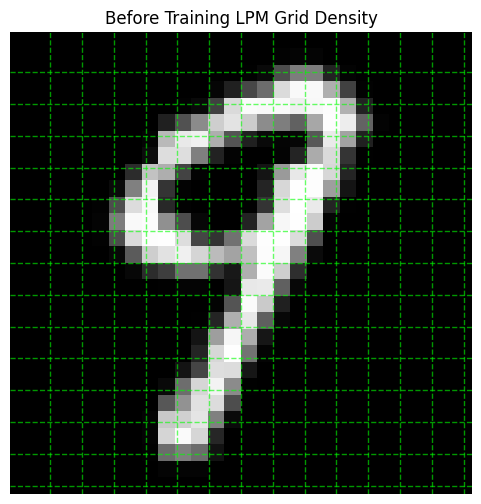

Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9015 - loss: 0.4202
✅ Saved best model to /content/backup_dir/emnist_vgg_lpm.keras (Epoch 1)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 262s 136ms/step - accuracy: 0.9543 - loss: 0.2320 - val_accuracy: 0.9888 - val_loss: 0.0640 - learning_rate: 0.0010
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9809 - loss: 0.1183
✅ Saved best model to /content/backup_dir/emnist_vgg_lpm.keras (Epoch 2)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 259s 135ms/step - accuracy: 0.9817 - loss: 0.1122 - val_accuracy: 0.9896 - val_loss: 0.0548 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


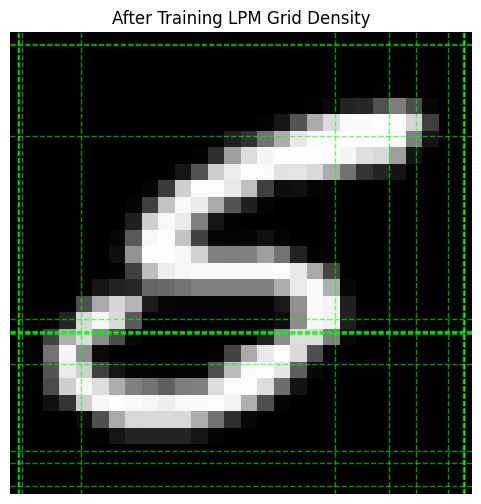

In [41]:
global epochs, early_stop, reduce_lr, checkpoint, BackupRestored

# 3. Build the model BEFORE loading to avoid the optimizer warning
# This "pre-builds" the optimizer variables so the loader can fill them
dummy_input = tf.zeros((1, 28, 28, 1))
_ = model(dummy_input)

# Example Usage: Visualize LPM grid with loaded weights
sample_img, _ = next(iter(val_data.take(1)))
visualize_emnist_lpm_grid(model, sample_img[0].numpy())


# Train
history = model.fit(
    train_data,
    epochs=2,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr, checkpoint, BackupRestored],
    verbose=1
)

# LPM Grid After Training
sample_img, _ = next(iter(val_data.take(1)))
visualize_emnist_lpm_grid(model, sample_img[0].numpy(),
                         title="After Training LPM Grid Density")

Perfect Resume: Starting from Epoch 2


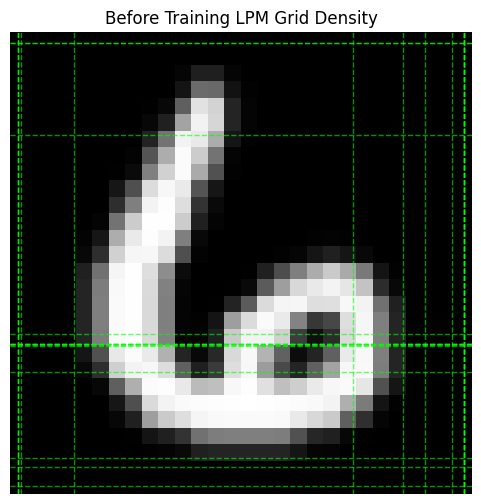

Epoch 3/4


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9842 - loss: 0.0983
✅ Saved best model to /content/backup_dir/emnist_vgg_lpm.keras (Epoch 3)
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 261s 137ms/step - accuracy: 0.9845 - loss: 0.0959 - val_accuracy: 0.9912 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 4/4


In [ ]:
# load model
from tensorflow.keras.models import load_model

global epochs, checkpoint, BackupRestored, early_stop, reduce_lr, model, base_model, optimizer_vgg, optimizer_lpm

# 1. Load the base_model (the Functional Keras model) that was saved by SaveInnerModel
loaded_base_model_architecture = load_model(
    f"{backup_dir}/emnist_vgg_lpm.keras", # This file contains the Functional model
    custom_objects={
        "LearnablePoolingModule": LearnablePoolingModule
    },
    compile=False # Do not compile yet, as DualOptimizerModel will handle it
)

# The loaded model is our 'base_model' for the new DualOptimizerModel
base_model = loaded_base_model_architecture

# 2. Re-initialize optimizers. Their state was NOT saved with the Functional model.
optimizer_vgg = tf.keras.optimizers.Adam(learning_rate=1e-3)
optimizer_lpm = tf.keras.optimizers.SGD(
    learning_rate=0.01, # Initial LR from paper
    momentum=0.9,       # Standard momentum for stable grid movement
    nesterov=True
)

# 3. Create a NEW DualOptimizerModel instance with the loaded base_model and re-initialized optimizers
model = DualOptimizerModel(base_model, optimizer_vgg, optimizer_lpm)

# 4. Build the model to ensure optimizers have variables before resuming training
dummy_input = tf.zeros((1, 28, 28, 1))
_ = model(dummy_input)

# 5. Re-compile the DualOptimizerModel
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)


def resume_training_state(model_wrapper, backup_dir):
    state_path = os.path.join(backup_dir, "training_state.json")
    vgg_opt_path = os.path.join(backup_dir, "vgg_opt_weights.npz")
    lpm_opt_path = os.path.join(backup_dir, "lpm_opt_weights.npz")

    initial_epoch = 0

    if os.path.exists(state_path):
        # 1. Load Epoch Metadata
        with open(state_path, 'r') as f:
            state = json.load(f)
            initial_epoch = state["epoch"]

        # 2. Initialize Optimizers (Keras needs one 'dummy' step to create variables)
        # We use the model's first trainable variables to trigger variable creation
        # Update in resume_training_state
        model_wrapper.optimizer_vgg.learning_rate.assign(state["vgg_lr"])
        model_wrapper.optimizer_lpm.learning_rate.assign(state["lpm_lr"])

        # Explicitly build optimizers before setting weights
        model_wrapper.optimizer_vgg.build(model_wrapper.vgg_trainable_variables)
        model_wrapper.optimizer_lpm.build(model_wrapper.lpm_trainable_variables)

        # 3. Inject Optimizer Weights
        if os.path.exists(vgg_opt_path):
            with np.load(vgg_opt_path) as data:
                weights = [data[f'arr_{i}'] for i in range(len(data.files))]
                model_wrapper.optimizer_vgg.set_weights(weights)

        if os.path.exists(lpm_opt_path):
            with np.load(lpm_opt_path) as data:
                weights = [data[f'arr_{i}'] for i in range(len(data.files))]
                model_wrapper.optimizer_lpm.set_weights(weights)

        print(f"Perfect Resume: Starting from Epoch {initial_epoch}")

    return initial_epoch

# --- APPLICATION ---
initial_epoch = resume_training_state(model, backup_dir)

checkpoint = SaveInnerModel(
    inner_model=base_model,
    vgg_opt=optimizer_vgg,
    lpm_opt=optimizer_lpm,
    filepath=f"{backup_dir}/emnist_vgg_lpm.keras",
    backup_dir=backup_dir,
    monitor='val_accuracy',
    save_weights_only=False

)

# Re-link the BackupRestored callback to the new model instance
BackupRestored.set_model(model)

# Example Usage: Visualize LPM grid with loaded weights (using the newly constructed 'model')
sample_img, _ = next(iter(val_data.take(1)))
visualize_emnist_lpm_grid(model, sample_img[0].numpy())

# 2. Start training by explicitly passing initial_epoch and setting total epochs.
#    If you want to run 2 *additional* epochs regardless of restoration, set epochs to `initial_epoch + 2`.
history = model.fit(
    train_data,
    epochs=initial_epoch + 2, # Run 2 additional epochs from the initial_epoch
    initial_epoch=initial_epoch, # Explicitly set the starting epoch
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr, checkpoint, BackupRestored],
    verbose=1
)

# LPM Grid After Training
sample_img, _ = next(iter(val_data.take(1)))
visualize_emnist_lpm_grid(model, sample_img[0].numpy(),
                         title="After Training LPM Grid Density")

# Plot Evaluation Curves

In [ ]:
# Plotting
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

def plot_evaluation_curves(y_true_labels, y_probs, class_names, set_name="Test"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))

    plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves - {set_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.subplot(1, 2, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'Class {class_names[i]}')
    plt.title(f'PR Curves - {set_name}')
    plt.tight_layout()
    plt.show()

# Final Evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(test_data)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nAccuracy (Test Set): {accuracy:.4f}")

# 3. Plot confusion matrix for test set
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plot_evaluation_curves(y_test_true, y_test_probs, target_names, set_name="Test")

# Visualizing Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
Displaying 32 feature maps for layer: block1_conv2


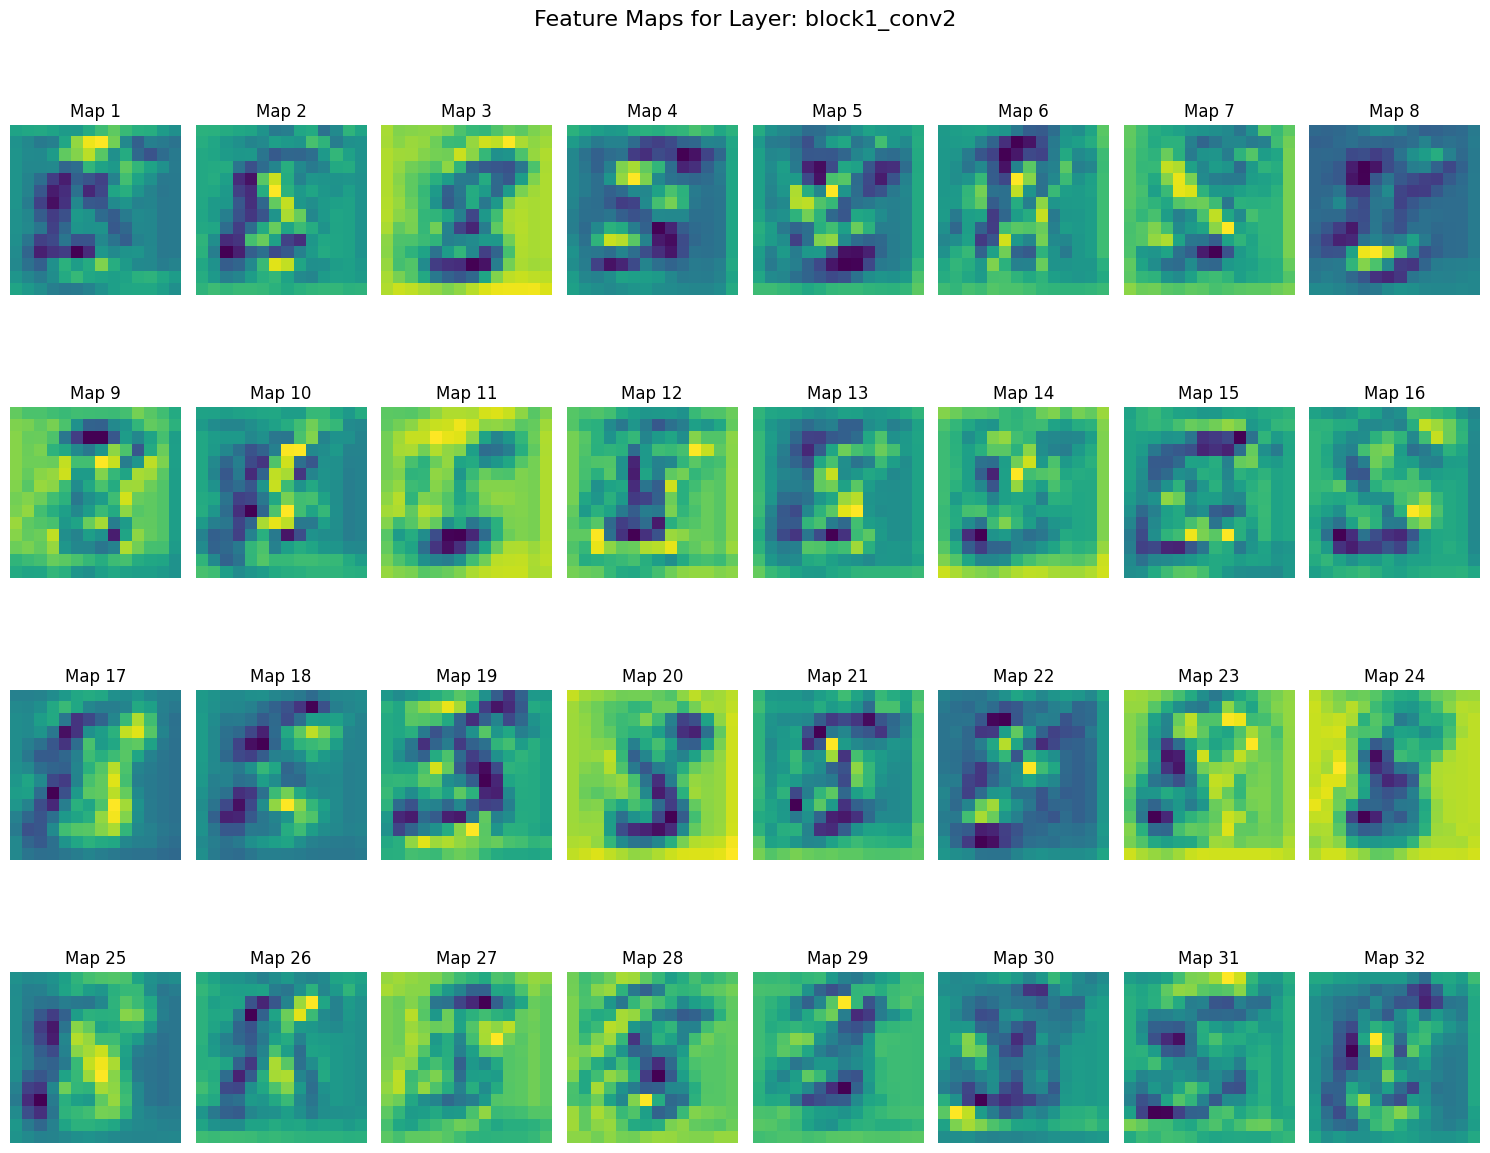

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Displaying 32 feature maps for layer: shortcut_transform


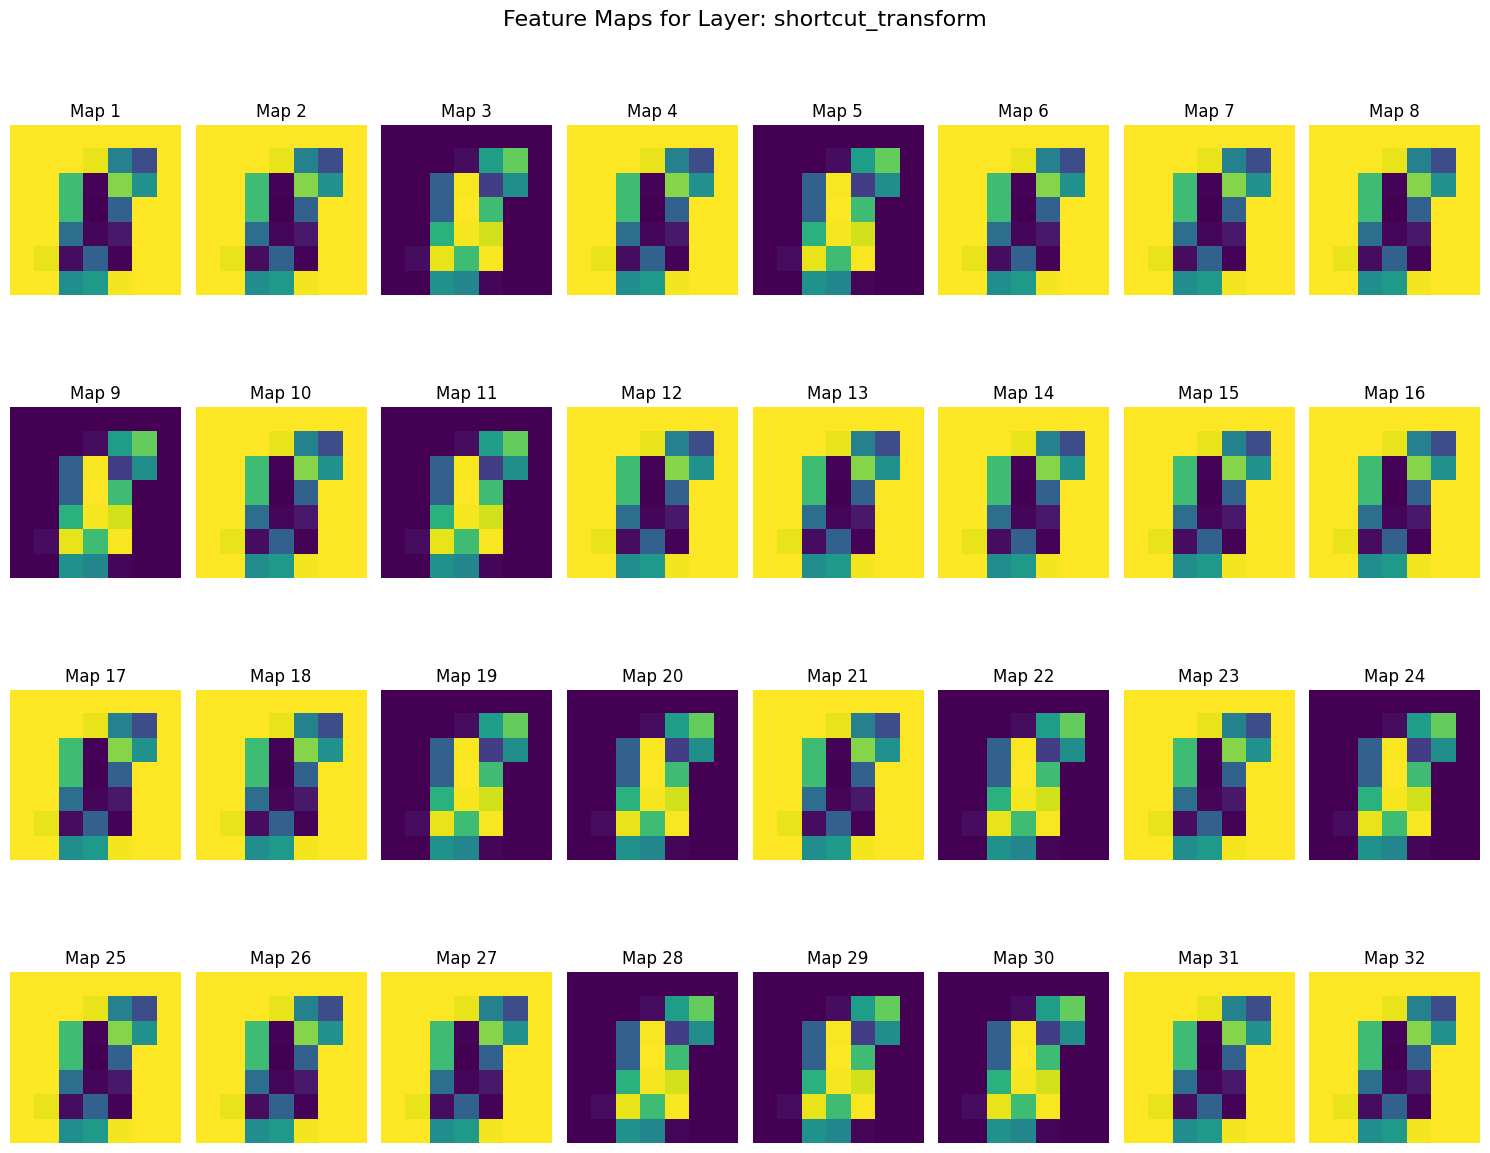

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
Displaying 32 feature maps for layer: shortcut_add


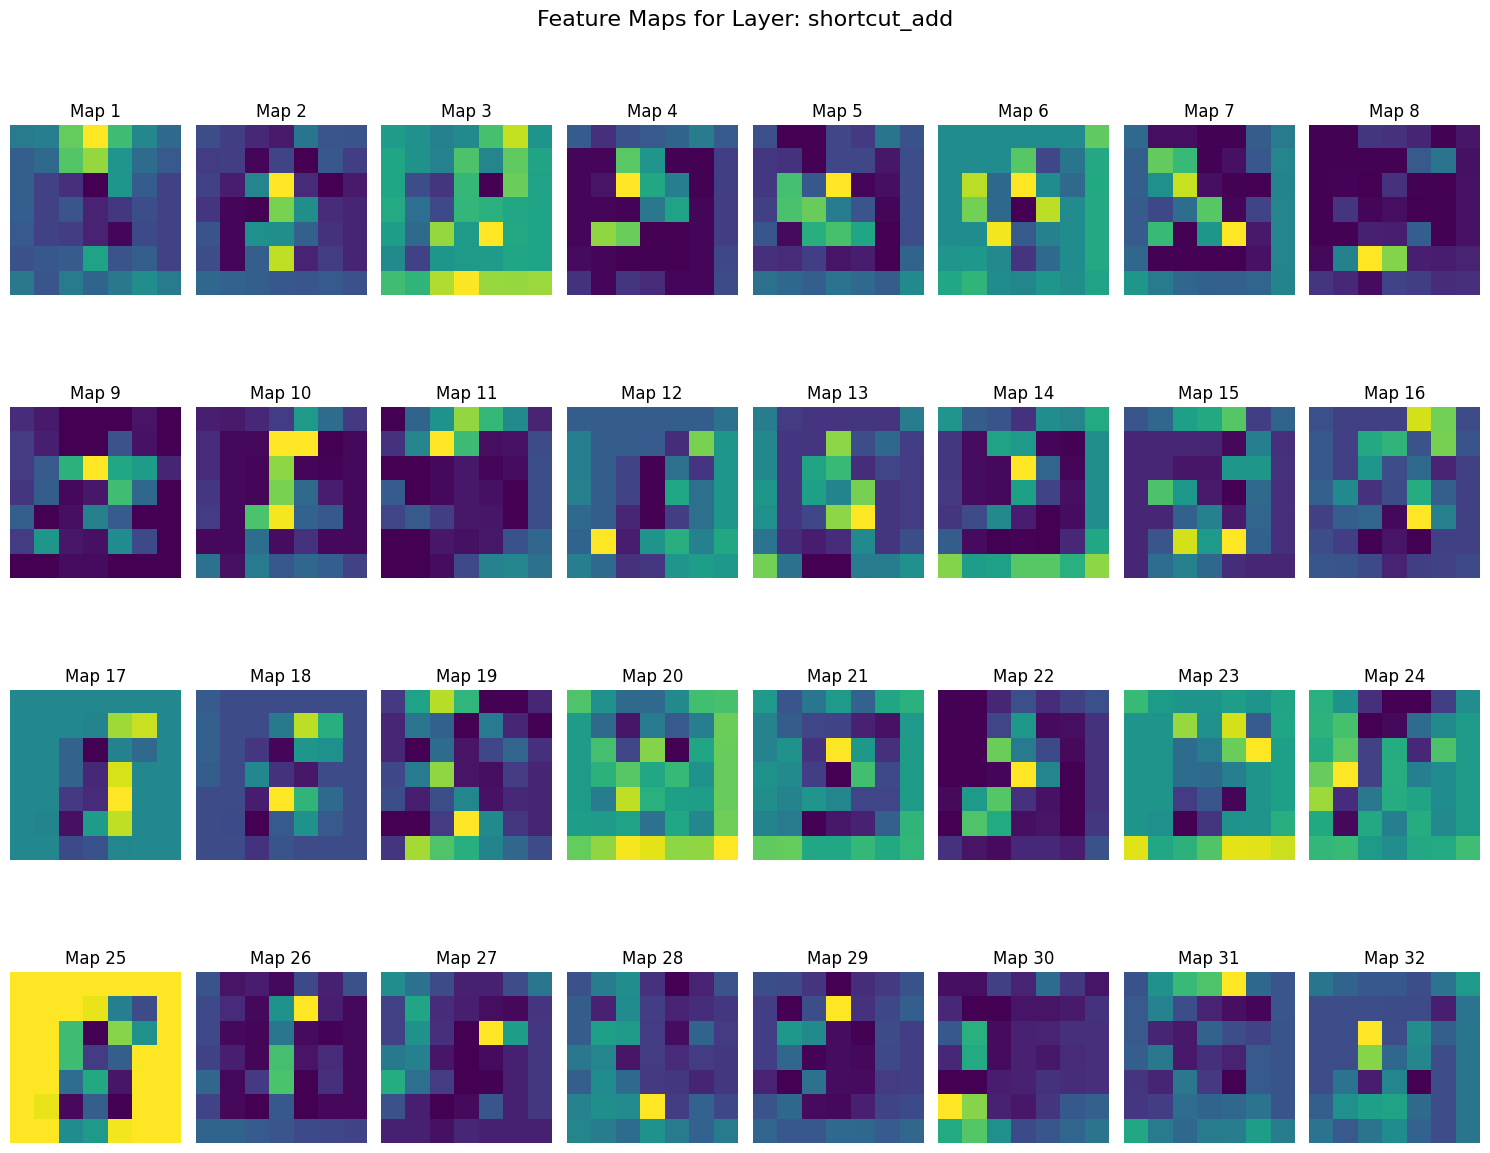

In [ ]:
def visualize_feature_maps(model, image_sample, layer_name, num_maps_to_display=None):
    """
    Visualizes feature maps from a specific layer in the model.

    Args:
        model (tf.keras.Model): The trained model (or DualOptimizerModel wrapper).
        image_sample (tf.Tensor or np.array): A single input image for which to generate feature maps.
        layer_name (str): The name of the layer whose output is to be visualized.
        num_maps_to_display (int, optional): The number of feature maps to display. If None, all maps will be displayed.
    """
    # If model is a DualOptimizerModel, get its internal model_arch
    if isinstance(model, DualOptimizerModel):
        keras_model = model.model_arch
    else:
        keras_model = model

    try:
        # Create a sub-model that outputs the feature maps of the specified layer
        intermediate_model = tf.keras.Model(
            inputs=keras_model.inputs,
            outputs=keras_model.get_layer(layer_name).output
        )
    except ValueError:
        print(f"Error: Layer '{layer_name}' not found in the model.")
        return

    # Prepare the image for prediction (add batch dimension if not present)
    if len(image_sample.shape) == 3: # (H, W, C)
        img_input = tf.expand_dims(image_sample, axis=0)
    elif len(image_sample.shape) == 4: # (B, H, W, C) already
        img_input = image_sample
    else:
        print("Error: Unsupported image_sample shape.")
        return

    # Get the feature maps
    feature_maps = intermediate_model.predict(img_input)

    num_filters = feature_maps.shape[-1]

    # Determine how many maps to display
    if num_maps_to_display is None:
        actual_maps_to_display = num_filters
    else:
        actual_maps_to_display = min(num_maps_to_display, num_filters)

    print(f"Displaying {actual_maps_to_display} feature maps for layer: {layer_name}")

    # Plot the feature maps
    cols = 8 # Number of columns in the plot grid
    rows = (actual_maps_to_display + cols - 1) // cols # Calculate number of rows needed (ceiling division)

    fig = plt.figure(figsize=(15, 3 * rows))
    for i in range(actual_maps_to_display):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis') # Assuming batch size 1
        ax.set_title(f'Map {i+1}')
        ax.axis('off')
    plt.tight_layout()
    plt.suptitle(f'Feature Maps for Layer: {layer_name}', fontsize=16, y=1.02)
    plt.show()

# Select a sample image from the validation data
sample_img_fm, _ = next(iter(val_data.take(1)))

# Visualize all feature maps for 'block1_conv2' layer
visualize_feature_maps(model, sample_img_fm[0].numpy(), layer_name='block1_conv2')

# Visualize all feature maps for 'Add' layer
visualize_feature_maps(model, sample_img_fm[0].numpy(), layer_name='shortcut_transform')

# Visualize all feature maps for 'Add' layer
visualize_feature_maps(model, sample_img_fm[0].numpy(), layer_name='shortcut_add')


# Plot TSNE
## Feature Extraction:
The provided HRNet model returns class probabilities. To visualize clusters, we must extract the high-dimensional vectors from the Flatten layer instead of the final softmax output

## Explanation of the Architecture Link:
### Normalization:
Because the test_data passes through the prep_layer (which includes rescaling and normalization), the t-SNE will reflect the features learned on normalized grayscale images.
### Dimensionality:
The Flatten Layer outputs a vector of size (None, 3136), which t-SNE then reduces to 2 dimensions for visualization.

In [ ]:
def plot_tsne_embeddings(model, dataset, num_batches=300):
    """
    Generates and visualizes t-SNE embeddings of the feature extraction layer of the model.

    This function extracts embeddings from a specified layer (typically a Flatten
    layer before the final classification head) for a subset of the dataset. It then applies
    t-Distributed Stochastic Neighbor Embedding (t-SNE) to reduce the dimensionality of these
    embeddings to 2D for visualization, allowing for an inspection of the clustering of different
    classes in the feature space.

    Args:
        model (tf.keras.Model or DualOptimizerModel): The trained Keras model or its DualOptimizerModel wrapper.
        dataset (tf.data.Dataset): The dataset (e.g., test_data) from which to draw samples.
        num_batches (int, optional): The number of batches to process for generating embeddings.
                                     Defaults to 300.
    """
    # If model is a DualOptimizerModel, get its internal model_arch
    if isinstance(model, DualOptimizerModel):
        keras_model = model.model_arch
    else:
        keras_model = model

    # 1. Create a feature extractor model
    # We target the layer before the final Dropout and Dense layers
    try:
        # Dynamically find the pooling layer to get the feature embeddings
        # In this model, the pooling layer is the Flatten layer right before the dense layers.
        # Let's find the Flatten layer instead.
        gap_layer = next(l for l in keras_model.layers if isinstance(l, layers.Flatten))
        feature_extractor = models.Model(inputs=keras_model.input, outputs=gap_layer.output)
        print(f"Extracting features from layer: {gap_layer.name}")
    except StopIteration:
        # Fallback if the layer type search fails (e.g., Flatten not found or model structure changes)
        # For this specific model, the layer before the Dense(64) is a Flatten layer.
        # Accessing by index can be brittle, but as a fallback it might work if structure is known.
        feature_extractor = models.Model(inputs=keras_model.input, outputs=keras_model.layers[-3].output)
        print(f"Fallback: Extracting features from layer: {keras_model.layers[-3].name}")

    embeddings = []
    labels = []

    print(f"Processing {num_batches} batches...")
    for i, (images, labs) in enumerate(dataset):
        if i >= num_batches:
            break

        # 2. Predict embeddings (features) instead of class probabilities
        emb = feature_extractor.predict(images, verbose=0)
        embeddings.append(emb)

        # 3. Append integer labels directly as label_mode="int" is used
        labels.append(labs.numpy())

    # Concatenate all batches
    embeddings = np.vstack(embeddings)
    labels = np.concatenate(labels)

    # 4. Compute TSNE dimensionality reduction
    print("Computing t-SNE (this may take a moment)...")
    # Check if TSNE is imported, if not, import it
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.6, s=15)

    # Add a colorbar indicating the digit classes (0-9)
    cbar = plt.colorbar(scatter, ticks=range(10))
    cbar.set_label('EMNIST Digit Class')

    plt.title("t-SNE Visualization: VGG Flatten Features")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

plot_tsne_embeddings(model, test_data, num_batches=300)

# How to find the "Hardest Positives" and "Hardest Negatives" from test set to see exactly which images the model is still struggling with?

To identify the images your model struggles with, we need to find the Hardest Positive (the image of the same class furthest away in embedding space) and the Hardest Negative (the image of a different class closest in embedding space). `This process directly evaluates the effectiveness of label smoothing in your loss configuration`.

# Key Adjustments
## Feature Extraction:
Since your model ends in a Dense layer with softmax , we must create a sub-model to extract embeddings from the Flatten layer to calculate Euclidean distances.
## Label Handling:
Your EMNIST dataset uses label_mode='int'. We do not need to  convert these one-hot encoded tensors into integer labels using np.argmax.
## Preprocessing:
The visualization must account for the preprocessing_model (rescaling and normalization) defined in your model pipeline.

# How Visualization Validates Your Configuration
By identifying the Hardest Positive (the sample of the same class furthest from the anchor) and the Hardest Negative (the sample of a different class closest to the anchor), you are testing several components of your architecture:

## Feature Separation:
`It measures how well the model separates classes using 1560 features produced by the Flatten layer before the final dense output`.

## Distance Metrics:
The calculation of the Euclidean distance matrix—using the formula $d^2 = ||a||^2 + ||b||^2 - 2\langle a,b \rangle$—allows you to see if "Hard Negatives" are still distinct enough to avoid misclassification.Normalization Impact: It shows the result of your preprocessing_model, which includes fixed 1-pixel translations and rotations, ensuring the model is invariant to these small shifts

In [ ]:
def visualize_hard_triplets_final(model, dataset, num_anchors=50):
    """
    Visualizes Hard Triplets (Anchor, Hard Positive, Hard Negative)
    using embeddings from the modell feature extraction layer.
    """
    # If model is a DualOptimizerModel, get its internal model_arch
    if isinstance(model, DualOptimizerModel):
        keras_model = model.model_arch
    else:
        keras_model = model

    # 1. Create a Feature Extractor to get embeddings before the Softmax layer
    try:
        # First, try to find a Flatten layer as it's common in this model structure
        feature_layer = next(l for l in keras_model.layers if isinstance(l, layers.Flatten))
        feature_extractor = models.Model(inputs=keras_model.input, outputs=feature_layer.output)
        print(f"Extracting features from layer: {feature_layer.name}")
    except StopIteration:
        try:
            # Fallback to GlobalAveragePooling2D if Flatten is not found
            feature_layer = next(l for l in keras_model.layers if isinstance(l, layers.GlobalAveragePooling2D))
            feature_extractor = models.Model(inputs=keras_model.input, outputs=feature_layer.output)
            print(f"Extracting features from layer: {feature_layer.name}")
        except StopIteration:
            # As a last resort, use the layer before the final dense layers
            feature_extractor = models.Model(inputs=keras_model.input, outputs=keras_model.layers[-3].output)
            print(f"Fallback: Extracting features from layer: {keras_model.layers[-3].name}")

    found_diverse_batch = False
    print("Searching for a diverse batch of images...")

    # Try to find a batch with multiple classes
    for attempt in range(10):
        # Unbatch and re-batch to ensure class diversity
        diverse_sample = dataset.unbatch().shuffle(10000).batch(128).take(300)

        for images, labels_tensor in diverse_sample:
            # Labels are already integers since label_mode="int" is used
            labels = labels_tensor.numpy()
            unique_classes = np.unique(labels)

            if len(unique_classes) < 2:
                continue

            found_diverse_batch = True
            print(f"✅ Success! Found {len(unique_classes)} unique classes.")

            # 2. Extract Embeddings for distance calculation
            embeddings = feature_extractor.predict(images, verbose=0)

            # 3. Calculate Euclidean Distance Matrix
            # Use the formula: ||a-b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
            dot_product = np.dot(embeddings, embeddings.T)
            square_norm = np.diag(dot_product)
            distances = np.maximum(square_norm[:, None] - 2.0 * dot_product + square_norm[None, :], 0.0)
            distances = np.sqrt(distances)

            plt.figure(figsize=(15, num_anchors * 4))

            found_count = 0
            for i in range(len(labels)):
                if found_count >= num_anchors: break

                anchor_label = labels[i]
                mask_pos = (labels == anchor_label)
                mask_neg = (labels != anchor_label)

                # Ensure there are samples to compare against
                if np.sum(mask_pos) < 2 or np.sum(mask_neg) == 0:
                    continue

                # Hardest Positive: Max distance to same-class image (ignore self)
                pos_indices = np.where(mask_pos)[0]
                pos_dists = distances[i][mask_pos]
                # To ignore self, set self-distance to a very small number for argmax
                temp_pos_dists = pos_dists.copy()
                self_in_pos_idx = np.where(pos_indices == i)[0]
                if self_in_pos_idx.size > 0: # Ensure index exists before modifying
                    temp_pos_dists[self_in_pos_idx] = -1
                hard_pos_idx = pos_indices[np.argmax(temp_pos_dists)]

                # Hardest Negative: Min distance to different-class image
                neg_indices = np.where(mask_neg)[0]
                neg_dists = distances[i][mask_neg]
                hard_neg_idx = neg_indices[np.argmin(neg_dists)]

                # 4. Plotting
                triplet_idx = [i, hard_pos_idx, hard_neg_idx]
                titles = ['Anchor', 'Hard Positive', 'Hard Negative']

                for col, idx in enumerate(triplet_idx):
                    plt.subplot(num_anchors, 3, found_count * 3 + col + 1)
                    # Squeeze grayscale images for plotting
                    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
                    plt.title(f"{titles[col]} (Class {labels[idx]})\nDist: {distances[i, idx]:.3f}")
                    plt.axis('off')

                found_count += 1

            plt.tight_layout()
            plt.show()
            return

    if not found_diverse_batch:
        print("❌ Could not find a diverse batch. Check dataset loading.")

# Run the visualization with your model and test_data
visualize_hard_triplets_final(model, test_data)

# Out Of Sample Testing


In [ ]:
# Constants
IMG_SIZE = (28, 28)
BATCH_SIZE = 128

# 1. Path to the Synthetic Dataset
DATA_DIR = "/kaggle/input/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/greyscale_synthetic_digits"

def get_oos_dataset():
    print("--- Loading Synthetic Font Digits ---")

    # 2. Load the dataset (28x28, Grayscale, 10 Classes)
    oos_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        labels='inferred',
        label_mode='int',
        color_mode='grayscale',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False  # Crucial for label comparison
    )

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(oos_ds.map(lambda x, y: x / 255.0).take(500))

    # Note: We do NOT use RandomRotation/Zoom/Translation for testing.
    # Testing should only include Rescaling and Normalization to match training.
    # Assuming 'prep_layer' from your training is already adapted:
    preprocessing_model = models.Sequential([
        layers.Rescaling(1./255),
        norm_layer
    ], name="inference_preprocessing")

    return oos_ds, preprocessing_model

# Get the dataset
oos_ds_raw, inference_prep = get_oos_dataset()


# ===============================================================
#  STEP 8: Plot Accuracy , Loss, And p-Values (GeM),
# and Confusion Matrix, ROC-Curve, PR-Curve
# ==============================================================
print("Running inference on Out-of-Sample synthetic digits...")
# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

def plot_evaluation_curves(y_true_labels, y_probs, class_names, set_name="Test"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))

    plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves - {set_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.subplot(1, 2, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'Class {class_names[i]}')
    plt.title(f'PR Curves - {set_name}')
    plt.tight_layout()
    plt.show()

# Final Evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(oos_ds_raw)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nAccuracy (Test Set): {accuracy:.4f}")

# 3. Plot confusion matrix for test set
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plot_evaluation_curves(y_test_true, y_test_probs, target_names, set_name="out-of-sample")